In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv('patients_cancer_poumon.csv', sep=';')
print(f"Shape: {df.shape}")
df.head()

Shape: (184, 20)


,patient_id,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,classe_jsrt_source,diagnostic_source,cancer_image,image_path
0,JPCLN001,53,1,1,5,1,0.7979,0.3379,34.9,1,1,1,1,92,0,2,malin,malignant,1,jsrt_subset/malin/JPCLN001.jpg
1,JPCLN002,78,0,1,5,1,0.7881,0.5322,31.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN002.jpg
2,JPCLN003,63,0,1,5,1,0.6362,0.2183,34.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN003.jpg
3,JPCLN004,68,0,1,5,1,0.2959,0.4082,28.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN004.jpg
4,JPCLN005,73,0,1,5,1,0.7021,0.3379,37.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN005.jpg


In [5]:
# Types des variables et valeurs manquantes
print("=== Types des variables ===")
print(df.dtypes)
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())
print("\n=== Statistiques descriptives ===")
df.describe()

=== Types des variables ===
patient_id                     str
age                          int64
sexe_masculin                int64
presence_nodule              int64
subtilite_nodule             int64
taille_nodule_px             int64
x_nodule_norm              float64
y_nodule_norm              float64
tabagisme_paquets_annee    float64
toux_chronique               int64
dyspnee                      int64
douleur_thoracique           int64
perte_poids                  int64
spo2                         int64
antecedent_familial          int64
risque_malignite             int64
classe_jsrt_source             str
diagnostic_source              str
cancer_image                 int64
image_path                     str
dtype: object

=== Valeurs manquantes ===
patient_id                 0
age                        0
sexe_masculin              0
presence_nodule            0
subtilite_nodule           0
taille_nodule_px           0
x_nodule_norm              0
y_nodule_norm              

,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,cancer_image
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000
mean,59.331522,0.456522,0.836957,2.581522,0.836957,0.383059,0.354977,30.212500,0.836957,0.543478,0.543478,0.543478,93.858696,0.320652,1.380435,0.543478
std,12.770521,0.499465,0.370413,1.286281,0.370413,0.280274,0.224145,7.769606,0.370413,0.499465,0.499465,0.499465,2.254717,0.468001,0.751572,0.499465
min,21.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,92.000000,0.000000,0.000000,0.000000
25%,51.000000,0.000000,1.000000,1.000000,1.000000,0.212925,0.195300,24.500000,1.000000,0.000000,0.000000,0.000000,92.000000,0.000000,1.000000,0.000000
50%,61.000000,0.000000,1.000000,3.000000,1.000000,0.289050,0.357900,31.400000,1.000000,1.000000,1.000000,1.000000,92.000000,0.000000,2.000000,1.000000
75%,69.000000,1.000000,1.000000,4.000000,1.000000,0.700675,0.520000,36.175000,1.000000,1.000000,1.000000,1.000000,95.000000,1.000000,2.000000,1.000000
max,80.000000,1.000000,1.000000,5.000000,1.000000,0.868200,0.828100,43.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,2.000000,1.000000


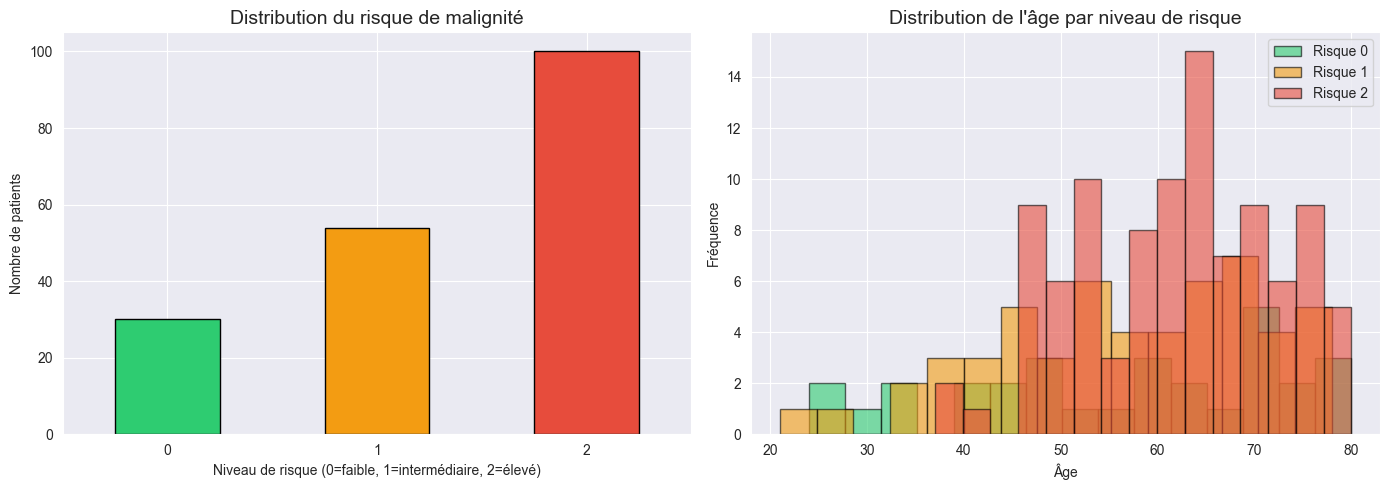

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualisation 1 : Distribution du risque de malignité
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['risque_malignite'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black'
)
axes[0].set_title('Distribution du risque de malignité', fontsize=14)
axes[0].set_xlabel('Niveau de risque (0=faible, 1=intermédiaire, 2=élevé)')
axes[0].set_ylabel('Nombre de patients')
axes[0].tick_params(axis='x', rotation=0)

# Visualisation 2 : Distribution de l'âge par risque
for i, risk in enumerate([0, 1, 2]):
    subset = df[df['risque_malignite'] == risk]['age']
    axes[1].hist(subset, bins=15, alpha=0.6, label=f'Risque {risk}', color=colors[i], edgecolor='black')
axes[1].set_title("Distribution de l'âge par niveau de risque", fontsize=14)
axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

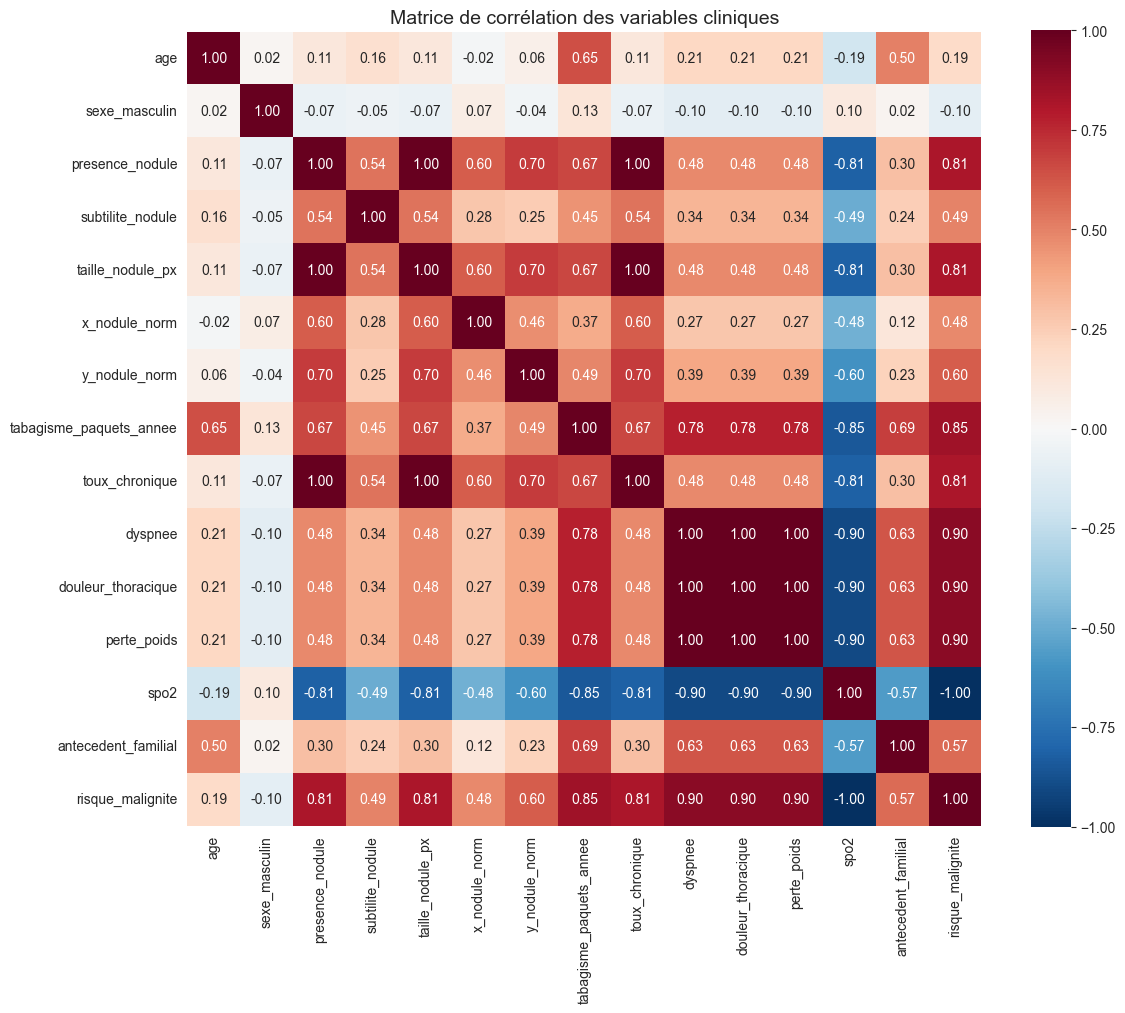

In [7]:
# Sélectionner les colonnes numériques pertinentes
cols_num = ['age', 'sexe_masculin', 'presence_nodule', 'subtilite_nodule',
            'taille_nodule_px', 'x_nodule_norm', 'y_nodule_norm',
            'tabagisme_paquets_annee', 'toux_chronique', 'dyspnee',
            'douleur_thoracique', 'perte_poids', 'spo2',
            'antecedent_familial', 'risque_malignite']

plt.figure(figsize=(12, 10))
sns.heatmap(df[cols_num].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Matrice de corrélation des variables cliniques', fontsize=14)
plt.tight_layout()
plt.show()

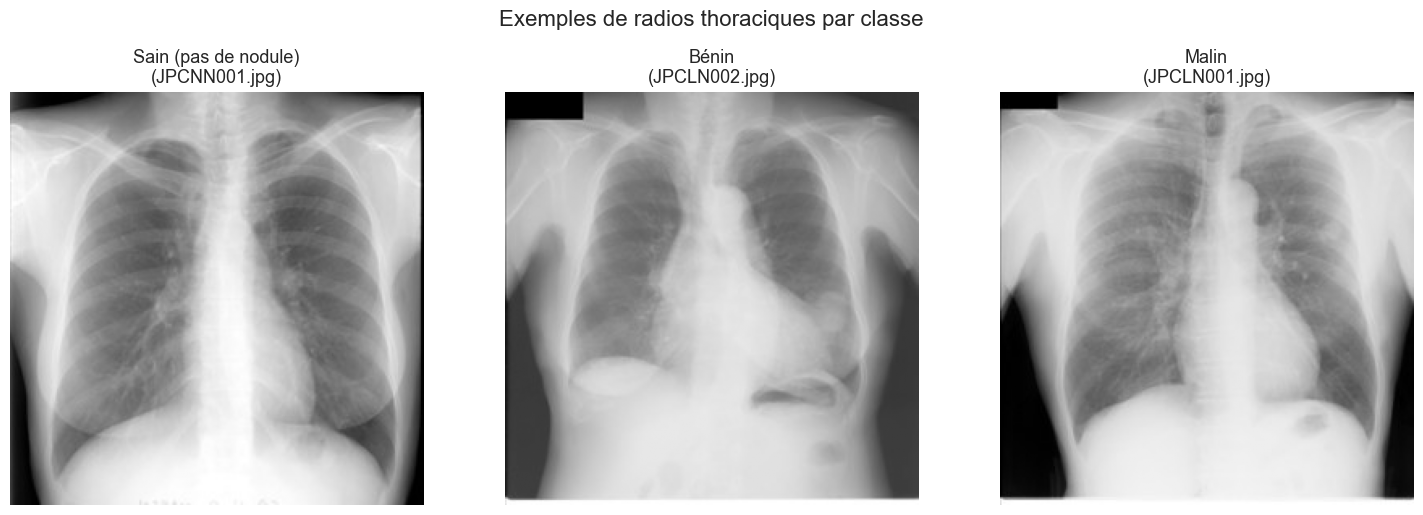

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
classes = ['sain', 'benin', 'malin']
titles = ['Sain (pas de nodule)', 'Bénin', 'Malin']

for i, (cls, title) in enumerate(zip(classes, titles)):
    folder = f'jsrt_subset/{cls}'
    img_name = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, img_name))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{title}\n({img_name})', fontsize=13)
    axes[i].axis('off')

plt.suptitle('Exemples de radios thoraciques par classe', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Partie 1

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Variables explicatives (features cliniques uniquement)
feature_cols = ['age', 'sexe_masculin', 'presence_nodule', 'subtilite_nodule',
                'taille_nodule_px', 'x_nodule_norm', 'y_nodule_norm',
                'tabagisme_paquets_annee', 'toux_chronique', 'dyspnee',
                'douleur_thoracique', 'perte_poids', 'spo2', 'antecedent_familial']

X = df[feature_cols].values
y = df['risque_malignite'].values

# Séparation train/test stratifiée (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation (centrage-réduction)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entraînement : {X_train_scaled.shape[0]} échantillons")
print(f"Test         : {X_test_scaled.shape[0]} échantillons")
print(f"\nDistribution train : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Distribution test  : {dict(zip(*np.unique(y_test, return_counts=True)))}")

Entraînement : 147 échantillons
Test         : 37 échantillons

Distribution train : {np.int64(0): np.int64(24), np.int64(1): np.int64(43), np.int64(2): np.int64(80)}
Distribution test  : {np.int64(0): np.int64(6), np.int64(1): np.int64(11), np.int64(2): np.int64(20)}


In [10]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'y_pred': y_pred}

    print(f"\nAccuracy : {acc:.4f}")
    print(f"\nRapport de classification :")
    print(classification_report(y_test, y_pred, target_names=['Faible', 'Intermédiaire', 'Élevé']))


  Random Forest

Accuracy : 1.0000

Rapport de classification :
               precision    recall  f1-score   support

       Faible       1.00      1.00      1.00         6
Intermédiaire       1.00      1.00      1.00        11
        Élevé       1.00      1.00      1.00        20

     accuracy                           1.00        37
    macro avg       1.00      1.00      1.00        37
 weighted avg       1.00      1.00      1.00        37


  SVM (RBF)

Accuracy : 1.0000

Rapport de classification :
               precision    recall  f1-score   support

       Faible       1.00      1.00      1.00         6
Intermédiaire       1.00      1.00      1.00        11
        Élevé       1.00      1.00      1.00        20

     accuracy                           1.00        37
    macro avg       1.00      1.00      1.00        37
 weighted avg       1.00      1.00      1.00        37


  Gradient Boosting

Accuracy : 1.0000

Rapport de classification :
               precision    r

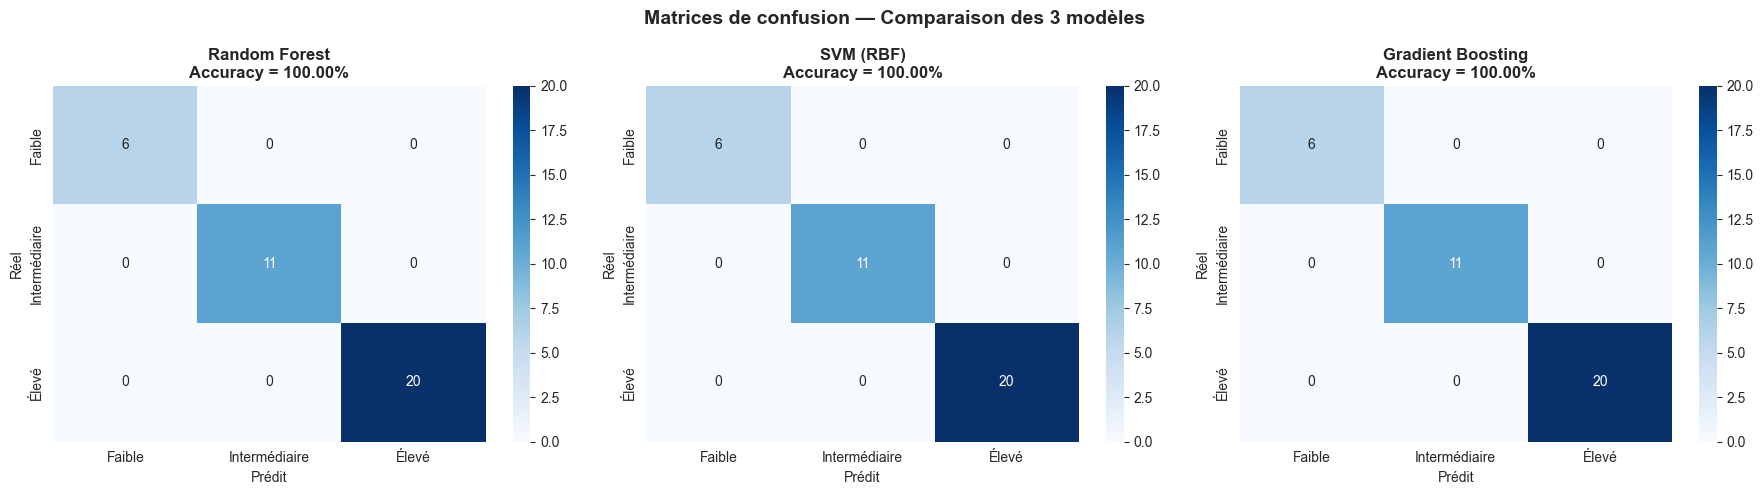

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Faible', 'Intermédiaire', 'Élevé']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    ax.set_title(f"{name}\nAccuracy = {res['accuracy']:.2%}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — Comparaison des 3 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

✅ Meilleur modèle : Random Forest (Accuracy = 1.0000)


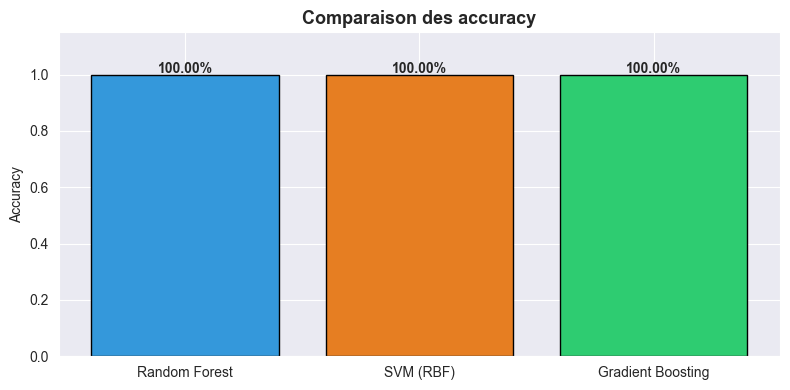


Probabilités (Random Forest) :


,P(Faible),P(Intermédiaire),P(Élevé),Classe réelle,Classe prédite
0,0.0,0.005,0.995,2,2
1,0.0,0.005,0.995,2,2
2,0.0,0.000,1.000,2,2
3,0.0,1.000,0.000,1,1
4,0.0,0.975,0.025,1,1
5,0.0,0.000,1.000,2,2
6,0.0,1.000,0.000,1,1
7,0.0,1.000,0.000,1,1
8,0.0,0.990,0.010,1,1
9,0.0,0.000,1.000,2,2


In [12]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
print(f"✅ Meilleur modèle : {best_name} (Accuracy = {results[best_name]['accuracy']:.4f})")

# Barplot comparatif
plt.figure(figsize=(8, 4))
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
colors = ['#3498db', '#e67e22', '#2ecc71']
bars = plt.bar(names, accs, color=colors, edgecolor='black')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.ylim(0, 1.15)
plt.title('Comparaison des accuracy', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# Probabilités de prédiction
proba_test = best_model.predict_proba(X_test_scaled)
proba_df = pd.DataFrame(proba_test, columns=['P(Faible)', 'P(Intermédiaire)', 'P(Élevé)'])
proba_df['Classe réelle'] = y_test
proba_df['Classe prédite'] = results[best_name]['y_pred']
print(f"\nProbabilités ({best_name}) :")
proba_df.head(10)

In [13]:
import joblib

joblib.dump(best_model, 'model1_tabular.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Modèle '{best_name}' sauvegardé")

# Probabilités sur TOUT le dataset → features pour le Modèle 2
X_all_scaled = scaler.transform(X)
proba_all = best_model.predict_proba(X_all_scaled)
df['proba_faible'] = proba_all[:, 0]
df['proba_intermediaire'] = proba_all[:, 1]
df['proba_eleve'] = proba_all[:, 2]

print("Probabilités ajoutées au DataFrame :")
df[['patient_id', 'risque_malignite', 'proba_faible', 'proba_intermediaire', 'proba_eleve']].head()

✅ Modèle 'Random Forest' sauvegardé
Probabilités ajoutées au DataFrame :


,patient_id,risque_malignite,proba_faible,proba_intermediaire,proba_eleve
0,JPCLN001,2,0.0,0.0,1.0
1,JPCLN002,1,0.0,1.0,0.0
2,JPCLN003,2,0.0,0.0,1.0
3,JPCLN004,1,0.0,1.0,0.0
4,JPCLN005,2,0.0,0.0,1.0


In [18]:
# Classification tabulaire (risque de malignité)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

IMG_SIZE = 128

def load_images(dataframe, img_size=IMG_SIZE):
    images = []
    for path in dataframe['image_path']:
        img = load_img(path, target_size=(img_size, img_size))
        img_array = img_to_array(img) / 255.0
        images.append(img_array)
    return np.array(images)

print("Chargement des images...")
X_images = load_images(df)
y_binary = df['cancer_image'].values
proba_features = df[['proba_faible', 'proba_intermediaire', 'proba_eleve']].values

print(f"Images chargées : {X_images.shape}")
print(f"Classes : {np.bincount(y_binary)} (0=non-cancer, 1=cancer)")

X_img_train, X_img_test, X_proba_train, X_proba_test, y_train_img, y_test_img = train_test_split(
    X_images, proba_features, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nTrain : {X_img_train.shape[0]} images")
print(f"Test  : {X_img_test.shape[0]} images")

Chargement des images...
Images chargées : (184, 128, 128, 3)
Classes : [ 84 100] (0=non-cancer, 1=cancer)

Train : 147 images
Test  : 37 images


In [19]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def build_image_model(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_image = build_image_model()

print("Entraînement du modèle image seul...")
history_image = model_image.fit(
    X_img_train, y_train_img,
    validation_data=(X_img_test, y_test_img),
    epochs=20, batch_size=16, verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Entraînement du modèle image seul...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.5170 - loss: 0.9553 - val_accuracy: 0.4595 - val_loss: 1.0599
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5306 - loss: 1.0002 - val_accuracy: 0.4865 - val_loss: 0.7039
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5646 - loss: 0.7185 - val_accuracy: 0.5405 - val_loss: 0.7395
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6122 - loss: 0.6655 - val_accuracy: 0.5405 - val_loss: 0.7473
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5986 - loss: 0.6799 - val_accuracy: 0.5135 - val_loss: 0.7355
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6054 - loss: 0.6339 - val_accuracy: 0.5946 - val_loss: 0.7136
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6395 - loss: 0.5899 - val_accuracy: 0.5676 - val_loss: 0.7433
Epoch 8/20
10/10 ━━━━━━━

In [20]:
def build_multimodal_model(img_shape=(IMG_SIZE, IMG_SIZE, 3), n_tabular=3):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=img_shape)
    base.trainable = False

    img_input = base.input
    x_img = base.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(64, activation='relu')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    tab_input = layers.Input(shape=(n_tabular,), name='tabular_input')
    x_tab = layers.Dense(16, activation='relu')(tab_input)
    x_tab = layers.Dropout(0.2)(x_tab)

    merged = layers.Concatenate()([x_img, x_tab])
    x = layers.Dense(64, activation='relu')(merged)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[img_input, tab_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_multi = build_multimodal_model()

print("Entraînement du modèle multimodal...")
history_multi = model_multi.fit(
    [X_img_train, X_proba_train], y_train_img,
    validation_data=([X_img_test, X_proba_test], y_test_img),
    epochs=20, batch_size=16, verbose=1
)

Entraînement du modèle multimodal...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - accuracy: 0.4966 - loss: 0.7917 - val_accuracy: 0.5676 - val_loss: 0.6692
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5306 - loss: 0.7394 - val_accuracy: 0.7297 - val_loss: 0.6340
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6190 - loss: 0.6576 - val_accuracy: 0.5946 - val_loss: 0.6294
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7007 - loss: 0.5783 - val_accuracy: 0.7297 - val_loss: 0.5817
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7211 - loss: 0.5640 - val_accuracy: 0.7568 - val_loss: 0.5651
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7959 - loss: 0.4603 - val_accuracy: 0.7568 - val_loss: 0.5374
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8367 - loss: 0.4414 - val_accuracy: 0.7838 - val_loss: 0.5157
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8367 - l

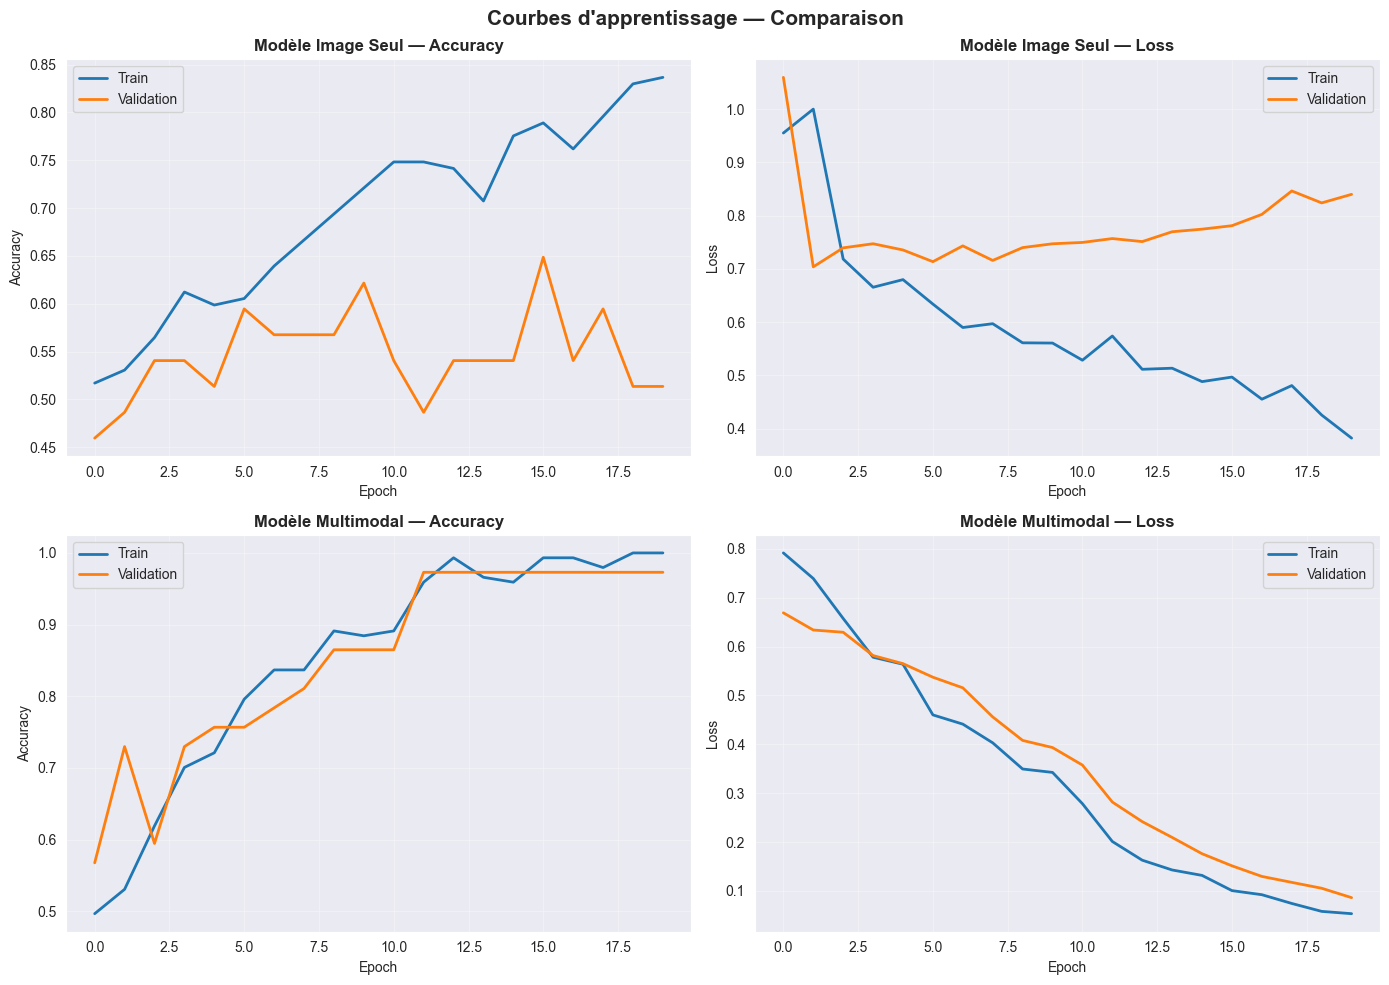

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].plot(history_image.history['accuracy'], label='Train', linewidth=2)
axes[0][0].plot(history_image.history['val_accuracy'], label='Validation', linewidth=2)
axes[0][0].set_title('Modèle Image Seul — Accuracy', fontweight='bold')
axes[0][0].set_xlabel('Epoch'); axes[0][0].set_ylabel('Accuracy')
axes[0][0].legend(); axes[0][0].grid(True, alpha=0.3)

axes[0][1].plot(history_image.history['loss'], label='Train', linewidth=2)
axes[0][1].plot(history_image.history['val_loss'], label='Validation', linewidth=2)
axes[0][1].set_title('Modèle Image Seul — Loss', fontweight='bold')
axes[0][1].set_xlabel('Epoch'); axes[0][1].set_ylabel('Loss')
axes[0][1].legend(); axes[0][1].grid(True, alpha=0.3)

axes[1][0].plot(history_multi.history['accuracy'], label='Train', linewidth=2)
axes[1][0].plot(history_multi.history['val_accuracy'], label='Validation', linewidth=2)
axes[1][0].set_title('Modèle Multimodal — Accuracy', fontweight='bold')
axes[1][0].set_xlabel('Epoch'); axes[1][0].set_ylabel('Accuracy')
axes[1][0].legend(); axes[1][0].grid(True, alpha=0.3)

axes[1][1].plot(history_multi.history['loss'], label='Train', linewidth=2)
axes[1][1].plot(history_multi.history['val_loss'], label='Validation', linewidth=2)
axes[1][1].set_title('Modèle Multimodal — Loss', fontweight='bold')
axes[1][1].set_xlabel('Epoch'); axes[1][1].set_ylabel('Loss')
axes[1][1].legend(); axes[1][1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — Comparaison", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_img = (model_image.predict(X_img_test) > 0.5).astype(int).flatten()
acc_img = accuracy_score(y_test_img, y_pred_img)
auc_img = roc_auc_score(y_test_img, model_image.predict(X_img_test))

y_pred_multi = (model_multi.predict([X_img_test, X_proba_test]) > 0.5).astype(int).flatten()
acc_multi = accuracy_score(y_test_img, y_pred_multi)
auc_multi = roc_auc_score(y_test_img, model_multi.predict([X_img_test, X_proba_test]))

print(f"{'Métrique':<20} {'Image seul':<15} {'Multimodal':<15}")
print("-" * 50)
print(f"{'Accuracy':<20} {acc_img:<15.4f} {acc_multi:<15.4f}")
print(f"{'AUC-ROC':<20} {auc_img:<15.4f} {auc_multi:<15.4f}")

print(f"\n--- Modèle Image Seul ---")
print(classification_report(y_test_img, y_pred_img, target_names=['Non-cancer', 'Cancer']))
print(f"--- Modèle Multimodal ---")
print(classification_report(y_test_img, y_pred_multi, target_names=['Non-cancer', 'Cancer']))

# Sauvegarde
model_image.save('model2_image.keras')
model_multi.save('model2_multimodal.keras')
print("✅ Modèles sauvegardés")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 956ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step 
Métrique             Image seul      Multimodal     
--------------------------------------------------
Accuracy             0.5135          0.9730         
AUC-ROC              0.5618          1.0000         

--- Modèle Image Seul ---
              precision    recall  f1-score   support

  Non-cancer       0.48      0.59      0.53        17
      Cancer       0.56      0.45      0.50        20

    accuracy                           0.51        37
   macro avg       0.52      0.52      0.51        37
weighted avg       0.52      0.51      0.51        37

--- Modèle Multimodal ---
              precision    recall  f1-score   support

  Non-cancer       1.00      0.94      0.97        17
      Cancer       0.95      1.00      0.98        20

    accuracy                           0.97        37
   macro avg       0.98      0.97      